<a href="https://colab.research.google.com/github/peculab/DFTDescriptorPipeline/blob/main/examples/indigo_aryl_alkyl/indigo_aryl_alkyl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
!rm -rf /usr/local/lib/python3.11/dist-packages/descriptors

In [40]:
# ✅ Reset environment
%cd /content
import shutil, os, sys, importlib

# 🔁 Uninstall pip-installed descriptors
!pip uninstall -y descriptors

# 🔥 Clear cached modules
for k in list(sys.modules.keys()):
    if k.startswith("descriptors"):
        del sys.modules[k]

# 🧹 Remove previous repo
if os.path.exists("DFTDescriptorPipeline"):
    shutil.rmtree("DFTDescriptorPipeline")

/content


In [41]:
# ✅ Install required packages
!pip install morfeus-ml scikit-learn joblib matplotlib openpyxl

# ✅ Clone the latest repo
!git clone https://github.com/peculab/DFTDescriptorPipeline.git

Cloning into 'DFTDescriptorPipeline'...
remote: Enumerating objects: 1041, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 1041 (delta 36), reused 26 (delta 26), pack-reused 987 (from 3)
Receiving objects: 100% (1041/1041), 39.41 MiB | 4.50 MiB/s, done.
Resolving deltas: 100% (589/589), done.
Updating files: 100% (87/87), done.


In [42]:
# ✅ Set module path
from morfeus import read_xyz, Sterimol
from morfeus.utils import get_radii

import shutil, os, sys, importlib
sys.path.insert(0, "/content/DFTDescriptorPipeline/descriptors")
import extractor_regr
import glob, os
importlib.reload(extractor_regr)

<module 'extractor_regr' from '/content/DFTDescriptorPipeline/descriptors/extractor_regr.py'>


[STEP1] Read Excel: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/N_aryl_N_alkyl_indigo.xlsx

[STEP2] Extracting log features for each unique Ar...

==== [1/21] [CYH-191-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-191-A.log ====
Found C1: 7, C2: 1, A: 9, B: 14, D: 8, F: 2, G: 6

==== [2/21] [CYH-196-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-196-A.log ====
Found C1: 11, C2: 1, A: 13, B: 21, D: 12, F: 2, G: 6

==== [3/21] [CYH-206-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-206-A.log ====
Found C1: 7, C2: 1, A: 9, B: 17, D: 8, F: 2, G: 6

==== [4/21] [CYH-209-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-209-A.log ====
Found C1: 7, C2: 1, A: 9, B: 18, D: 8, F: 2, G: 6

==== [5/21] [CYH-208-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-208-A.log ====
F

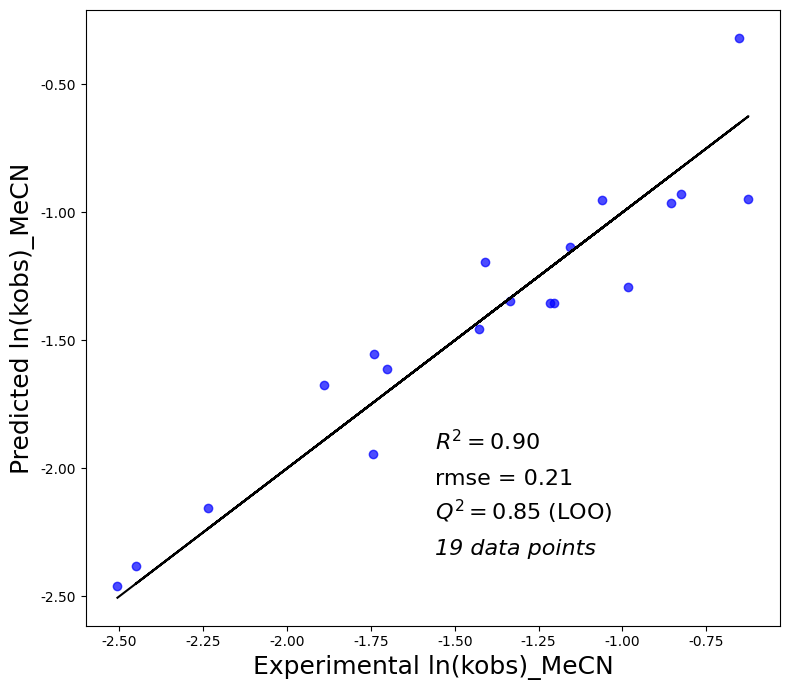


✅ Analysis complete!


In [43]:
data_dir = "/content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl"
xlsx_path = glob.glob(os.path.join(data_dir, "*.xlsx"))[0]
log_folder = os.path.join(data_dir, "logfiles")

# One-click execution
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,
    max_features=3,
    target='ln(kobs)_MeCN'
)

In [44]:
import pandas as pd

target = "ln(kobs)_MeCN"
features = [c for c in df.columns if c.startswith("Ar") and "_" in c and not c.endswith(("_Ar", "_Ar_key", "_log_path", "_log_exists"))]

mask_missing = df[features + [target]].isna().any(axis=1)
dropped = df[mask_missing].copy()
dropped["missing_features"] = (
    df[features + [target]]
    .isna()
    .apply(lambda row: [c for c, v in row.items() if v], axis=1)
)

print(f"org dataset: {len(df)}")
print(f"missing dataset: {mask_missing.sum()}")
display(dropped[["Compound", "Ar1", "missing_features"]])

org dataset: 21
missing dataset: 2


,Compound,Ar1,missing_features
14,PGOH-07,CYH-186-A,"[Ar1_Ar_f, Ar1_Ar_g]"
15,PGOH-26,CYH-247-A,"[Ar1_Ar_NBO_C2, Ar1_Ar_NBO_=O, Ar1_Ar_NBO_-O, ..."


In [45]:
need = [c for c in df.columns if c.endswith(("_Ar_f","_Ar_g"))]
missing = df[need].isna().any(axis=1)
print("missing f/g：", int(missing.sum()))
display(df.loc[missing, ["Compound","Ar1"] + need].head(10))

missing f/g： 2


,Compound,Ar1,Ar1_Ar_f,Ar1_Ar_g
14,PGOH-07,CYH-186-A,NaN,NaN
15,PGOH-26,CYH-247-A,NaN,NaN



[STEP1] Read Excel: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/N_aryl_N_alkyl_indigo.xlsx

[STEP2] Extracting log features for each unique Ar...

==== [1/21] [CYH-191-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-191-A.log ====
Found C1: 7, C2: 1, A: 9, B: 14, D: 8, F: 2, G: 6

==== [2/21] [CYH-196-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-196-A.log ====
Found C1: 11, C2: 1, A: 13, B: 21, D: 12, F: 2, G: 6

==== [3/21] [CYH-206-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-206-A.log ====
Found C1: 7, C2: 1, A: 9, B: 17, D: 8, F: 2, G: 6

==== [4/21] [CYH-209-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-209-A.log ====
Found C1: 7, C2: 1, A: 9, B: 18, D: 8, F: 2, G: 6

==== [5/21] [CYH-208-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-208-A.log ====
F

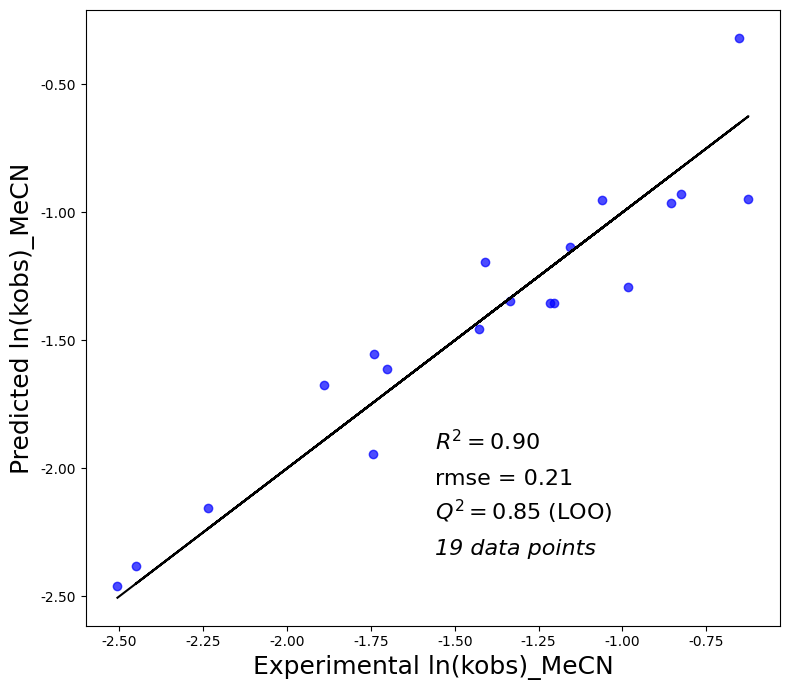


✅ Analysis complete!


In [46]:
# One-click execution
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,
    max_features=4,
    target='ln(kobs)_MeCN'
)


[STEP1] Read Excel: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/N_aryl_N_alkyl_indigo.xlsx

[STEP2] Extracting log features for each unique Ar...

==== [1/21] [CYH-191-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-191-A.log ====
Found C1: 7, C2: 1, A: 9, B: 14, D: 8, F: 2, G: 6

==== [2/21] [CYH-196-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-196-A.log ====
Found C1: 11, C2: 1, A: 13, B: 21, D: 12, F: 2, G: 6

==== [3/21] [CYH-206-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-206-A.log ====
Found C1: 7, C2: 1, A: 9, B: 17, D: 8, F: 2, G: 6

==== [4/21] [CYH-209-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-209-A.log ====
Found C1: 7, C2: 1, A: 9, B: 18, D: 8, F: 2, G: 6

==== [5/21] [CYH-208-A] Processing log: /content/DFTDescriptorPipeline/examples/indigo_aryl_alkyl/logfiles/CYH-208-A.log ====
F

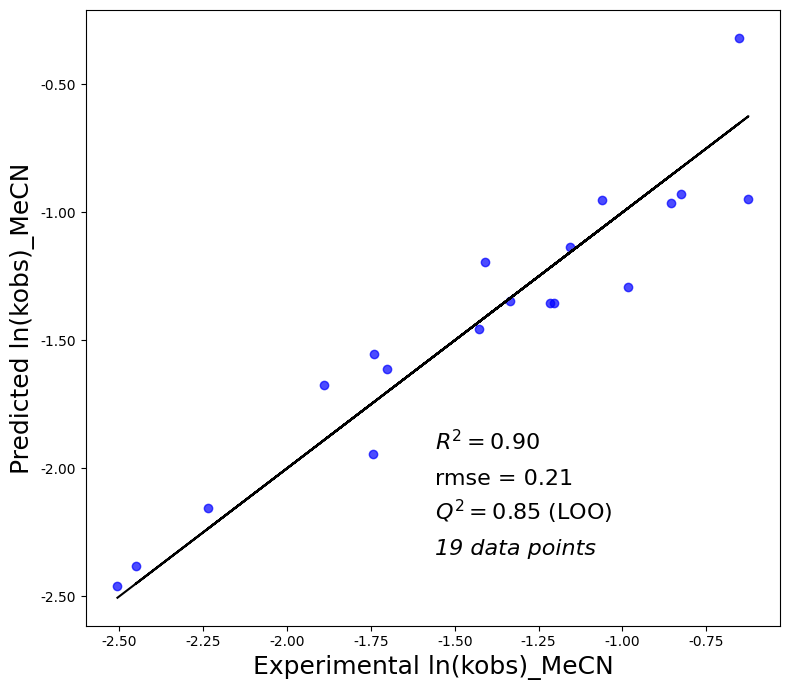


✅ Analysis complete!


In [47]:
# One-click execution
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,
    max_features=5,
    target='ln(kobs)_MeCN'
)